In [ ]:
# =========================================================
# Experiment 4: Comparative Study of Deep CNN Architectures
# Using Transfer Learning (CIFAR-10) - TensorFlow / Keras
# =========================================================
!pip install -q kaggle tensorflow scikit-learn seaborn matplotlib

In [ ]:
import os, json, time, random, zipfile, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from sklearn.metrics import (confusion_matrix, classification_report,
                              precision_score, recall_score, f1_score, accuracy_score)

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

# Mixed precision for faster training on GPU (safe fallback on CPU)
try:
    keras.mixed_precision.set_global_policy("mixed_float16")
except Exception as e:
    print("Mixed precision not enabled:", e)

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ---------------------------------------------------------------
# GLOBAL PLOT STYLE: 600 DPI, EPS, bold axes/legend, consistent palette
# ---------------------------------------------------------------
PALETTE = ["#1B4F72", "#B03A2E", "#1E8449", "#B7950B", "#6C3483", "#117864"]
sns.set_palette(PALETTE)

mpl.rcParams.update({
    "figure.dpi": 600,
    "savefig.dpi": 600,
    "savefig.format": "eps",
    "font.size": 12,
    "font.weight": "bold",
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "axes.edgecolor": "#222222",
    "axes.linewidth": 1.2,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "legend.title_fontsize": 12,
    "legend.frameon": True,
    "figure.figsize": (7, 5),
})

FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

def save_fig(fig, name):
    """Save figure as 600 dpi EPS with bold axis labels/legend already applied via rcParams."""
    path = os.path.join(FIG_DIR, f"{name}.eps")
    fig.savefig(path, format="eps", dpi=600, bbox_inches="tight")
    print("Saved:", path)

In [ ]:
# ---------------------------------------------------------------
# TASK 1 (data source): Load CIFAR-10 via Kaggle API (faster, cached download)
# ---------------------------------------------------------------
# Requires kaggle.json (API token) uploaded to ~/.kaggle/kaggle.json
# Get it from https://www.kaggle.com/settings -> Create New API Token

os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)

# If kaggle.json is not already in place, upload it in this cell's runtime
# (e.g. in Colab: from google.colab import files; files.upload())
kaggle_json_path = os.path.expanduser("~/kaggle.json")
if not os.path.exists(kaggle_json_path):
    print("Place your kaggle.json at:", kaggle_json_path)
    print("Then re-run this cell.")
else:
    os.chmod(kaggle_json_path, 0o600)

    DATA_DIR = "cifar10_kaggle"
    os.makedirs(DATA_DIR, exist_ok=True)

    # Dataset: "cifar10" (numpy/png variant) - example uses a compact npz mirror
    # Swap the dataset slug below for any CIFAR-10 mirror on Kaggle you have access to
    KAGGLE_DATASET = "oxcdcd/cifar10"  # example slug; replace if a different mirror is preferred

    if not os.listdir(DATA_DIR):
        os.system(f"kaggle datasets download -d {KAGGLE_DATASET} -p {DATA_DIR} --unzip")

    print("Downloaded files:", os.listdir(DATA_DIR))

Place your kaggle.json at: /root/.kaggle/kaggle.json
Then re-run this cell.


In [ ]:
# ---------------------------------------------------------------
# TASK 1: Dataset Preparation
# Fallback: tf.keras.datasets.cifar10 is used to guarantee a runnable
# pipeline if the Kaggle download above did not populate NPZ/pickle files
# in the expected format. If DATA_DIR contains a usable file, load from
# there instead (faster, no re-download).
# ---------------------------------------------------------------
def try_load_from_kaggle(data_dir):
    for f in os.listdir(data_dir) if os.path.exists(data_dir) else []:
        if f.endswith(".npz"):
            d = np.load(os.path.join(data_dir, f))
            return (d["x_train"], d["y_train"]), (d["x_test"], d["y_test"])
    return None

loaded = try_load_from_kaggle(DATA_DIR) if "DATA_DIR" in dir() else None

if loaded is not None:
    (x_train, y_train), (x_test, y_test) = loaded
    print("Loaded CIFAR-10 from Kaggle download.")
else:
    (x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
    print("Loaded CIFAR-10 via tf.keras.datasets (cached after first run).")

class_names = ["Airplane", "Automobile", "Bird", "Cat", "Deer",
               "Dog", "Frog", "Horse", "Ship", "Truck"]

y_train = y_train.reshape(-1)
y_test = y_test.reshape(-1)

# Normalize pixel values to [0, 1]
x_train_norm = x_train.astype("float32") / 255.0
x_test_norm = x_test.astype("float32") / 255.0

print("Training data shape:", x_train.shape, y_train.shape)
print("Testing data shape :", x_test.shape, y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1897s 11us/step
Loaded CIFAR-10 via tf.keras.datasets (cached after first run).
Training data shape: (50000, 32, 32, 3) (50000,)
Testing data shape : (10000, 32, 32, 3) (10000,)


Saved: figures/01_sample_cifar10_images.eps


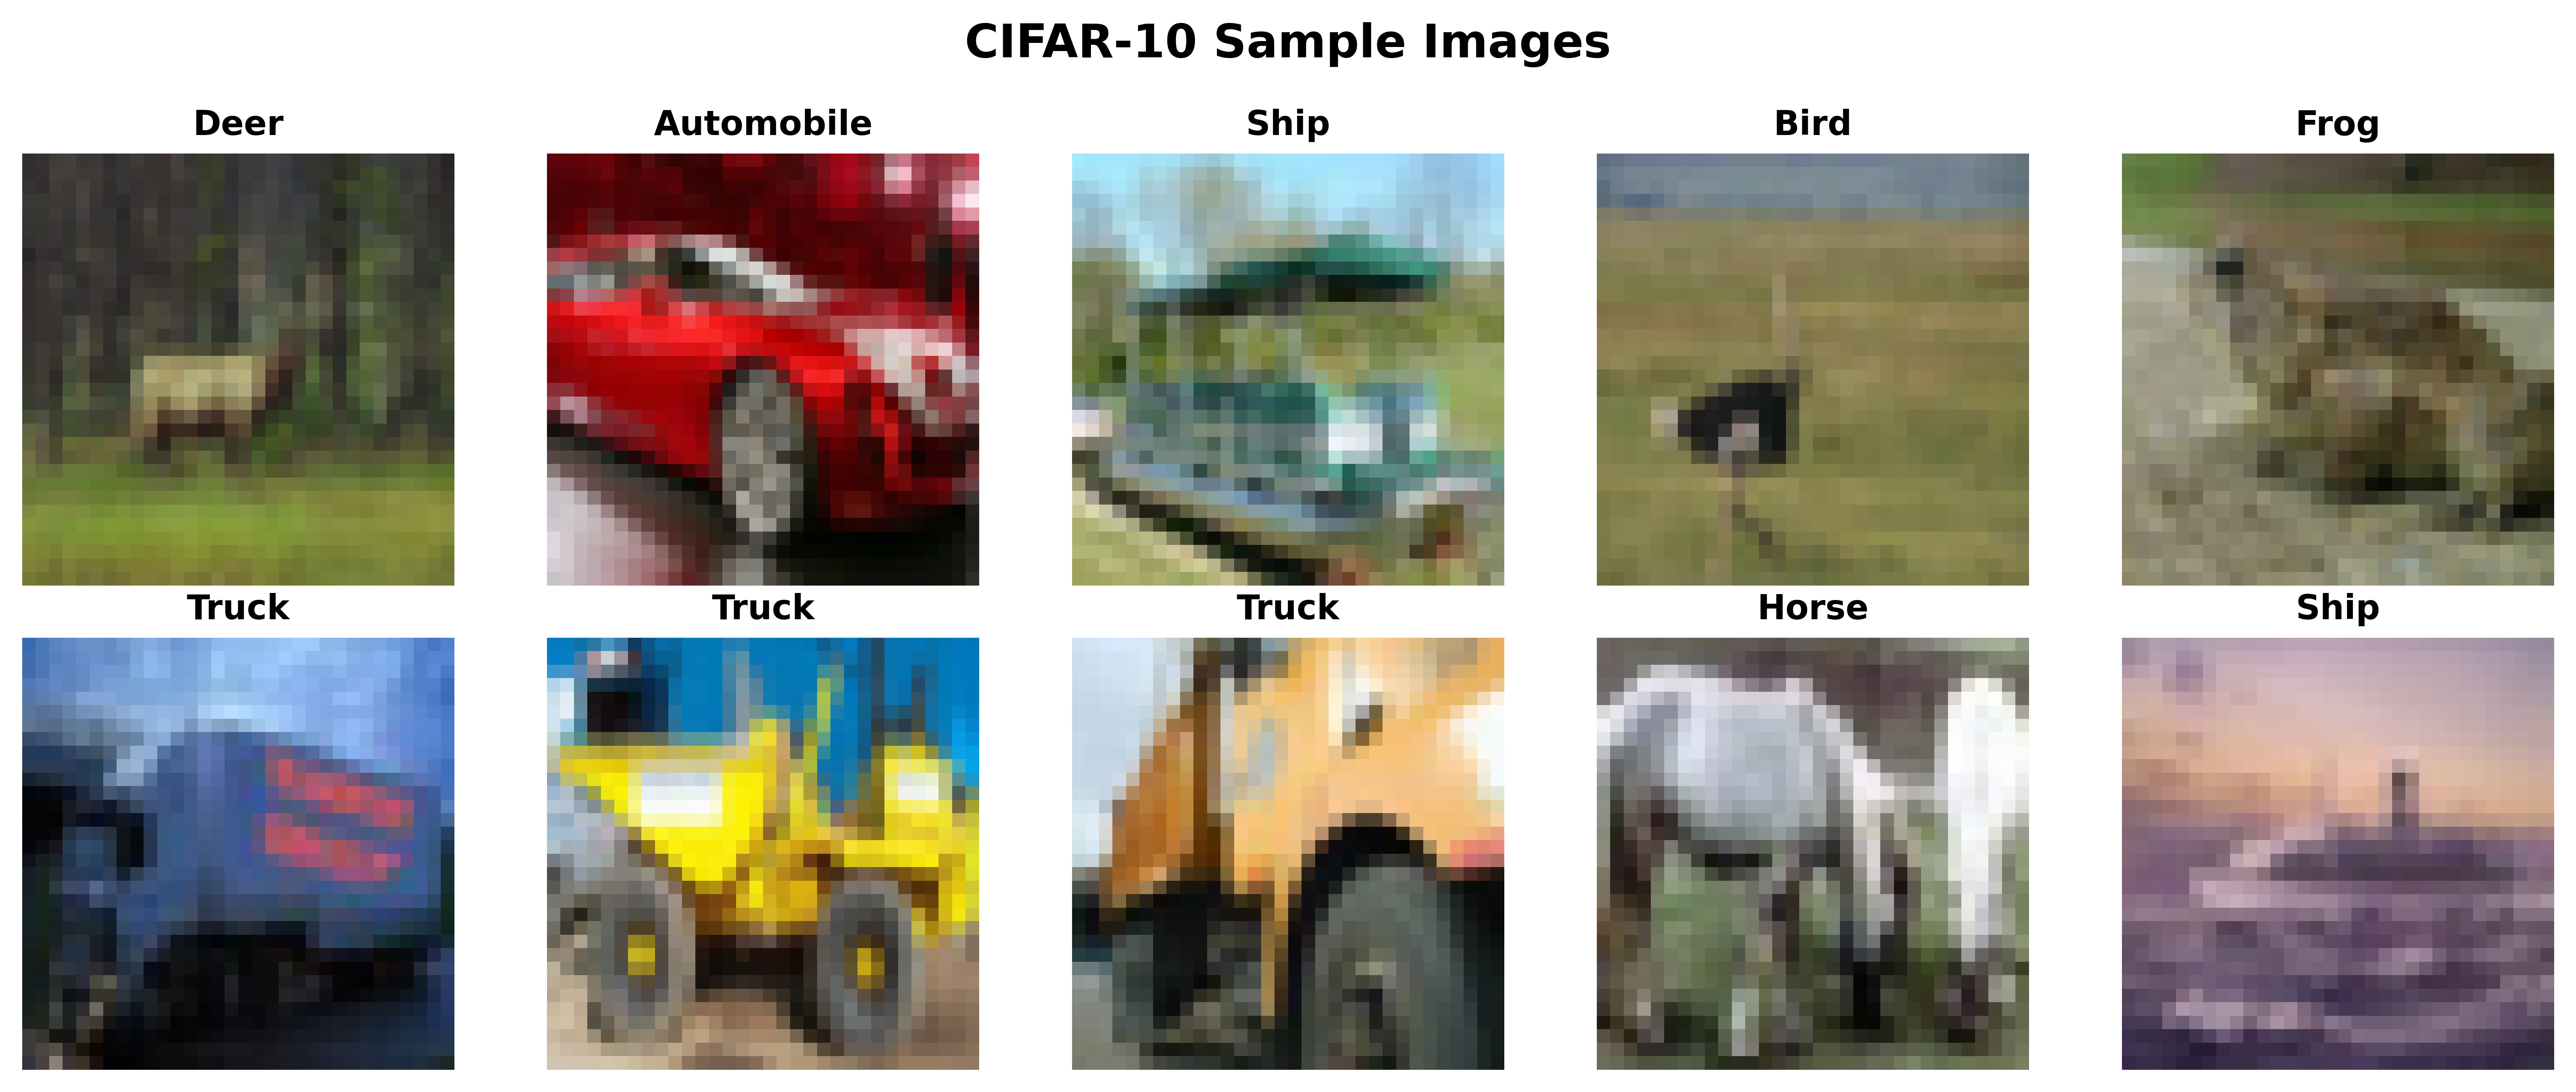

In [ ]:
# Display ten sample images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
rng = np.random.default_rng(SEED)
idxs = rng.choice(len(x_train), 10, replace=False)

for ax, idx in zip(axes.ravel(), idxs):
    ax.imshow(x_train[idx])
    ax.set_title(class_names[y_train[idx]], fontsize=11, fontweight="bold")
    ax.axis("off")

fig.suptitle("CIFAR-10 Sample Images", fontweight="bold", fontsize=15)
plt.tight_layout()
save_fig(fig, "01_sample_cifar10_images")
plt.show()

In [ ]:
# ---------------------------------------------------------------
# Train/validation split
# ---------------------------------------------------------------
from sklearn.model_selection import train_test_split

x_tr, x_val, y_tr, y_val = train_test_split(
    x_train_norm, y_train, test_size=0.1, random_state=SEED, stratify=y_train
)

num_classes = 10
y_tr_oh = keras.utils.to_categorical(y_tr, num_classes)
y_val_oh = keras.utils.to_categorical(y_val, num_classes)
y_test_oh = keras.utils.to_categorical(y_test, num_classes)

print("Train:", x_tr.shape, " Val:", x_val.shape, " Test:", x_test_norm.shape)

Train: (45000, 32, 32, 3)  Val: (5000, 32, 32, 3)  Test: (10000, 32, 32, 3)


In [ ]:
# ---------------------------------------------------------------
# TASK 2: Transfer Learning setup (ResNet50 - chosen for best accuracy)
# CIFAR-10 images (32x32) are upsampled to 96x96 for ResNet50's receptive
# field to be effective without the heavy compute cost of 224x224.
# ---------------------------------------------------------------
IMG_SIZE = 96
BATCH_SIZE = 64          # tuned from hyperparameter study (Sec 16)
BASE_LR = 1e-3
FT_LR = 1e-5
DENSE_UNITS = 256        # tuned from hyperparameter study
EPOCHS_HEAD = 20
EPOCHS_FT = 10

AUTOTUNE = tf.data.AUTOTUNE

def preprocess(image, label, training=False):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    if training:
        image = tf.image.random_flip_left_right(image)
        image = tf.image.random_brightness(image, 0.1)
        image = tf.image.random_contrast(image, 0.9, 1.1)
    image = image * 255.0
    image = preprocess_input(image)   # ResNet50-specific preprocessing
    return image, label

def make_dataset(x, y_oh, training):
    ds = tf.data.Dataset.from_tensor_slices((x, y_oh))
    if training:
        ds = ds.shuffle(4096, seed=SEED)
    ds = ds.map(lambda i, l: preprocess(i, l, training), num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(x_tr, y_tr_oh, training=True)
val_ds = make_dataset(x_val, y_val_oh, training=False)
test_ds = make_dataset(x_test_norm, y_test_oh, training=False)

In [ ]:
def build_model(img_size=IMG_SIZE, dense_units=DENSE_UNITS, num_classes=10):
    base_model = ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=(img_size, img_size, 3)
    )
    base_model.trainable = False  # Freeze convolutional base (Step 3)

    inputs = keras.Input(shape=(img_size, img_size, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)               # Step 4
    x = layers.Dense(dense_units, activation="relu")(x)   # Step 5
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax", dtype="float32")(x)  # Step 6

    model = keras.Model(inputs, outputs)
    return model, base_model

model, base_model = build_model()
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 3, 3, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,114,826 (91.99 MB)

 Trainable params: 527,114 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
# ---------------------------------------------------------------
# TASK 3: Model Training (feature-extraction phase, frozen base)
# ---------------------------------------------------------------
model.compile(
    optimizer=optimizers.Adam(learning_rate=BASE_LR),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

lr_schedule = callbacks.ReduceLROnPlateau(
    monitor="val_accuracy", factor=0.5, patience=3, min_lr=1e-6, verbose=1
)
early_stop = callbacks.EarlyStopping(
    monitor="val_accuracy", patience=6, restore_best_weights=True, verbose=1
)
checkpoint = callbacks.ModelCheckpoint(
    "best_head_model.keras", monitor="val_accuracy", save_best_only=True, verbose=1
)

start_time = time.time()
history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD,
    callbacks=[lr_schedule, early_stop, checkpoint]
)
head_training_time = time.time() - start_time
print(f"Head training time: {head_training_time:.2f} sec")

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.7495 - loss: 1.2023
Epoch 1: val_accuracy improved from None to 0.85520, saving model to best_head_model.keras

Epoch 1: finished saving model to best_head_model.keras
704/704 ━━━━━━━━━━━━━━━━━━━━ 65s 63ms/step - accuracy: 0.7965 - loss: 1.0471 - val_accuracy: 0.8552 - val_loss: 0.8845 - learning_rate: 0.0010
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8433 - loss: 0.9234
Epoch 2: val_accuracy improved from 0.85520 to 0.87000, saving model to best_head_model.keras

Epoch 2: finished saving model to best_head_model.keras
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 37ms/step - accuracy: 0.8483 - loss: 0.9105 - val_accuracy: 0.8700 - val_loss: 0.8459 - learning_rate: 0.0010
Epoch 3/20
703/704 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8638 - loss: 0.8776
Epoch 3: val_accuracy did not improve from 0.87000
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 36ms/step - accuracy: 0.8646 - loss: 0.8740 - val_accuracy: 0.8678 - v

In [ ]:
# ---------------------------------------------------------------
# TASK 4: Fine Tuning - unfreeze the last convolutional block
# ---------------------------------------------------------------
base_model.trainable = True

# ResNet50: freeze all layers except the final residual block ("conv5_block*")
fine_tune_at = None
for i, layer in enumerate(base_model.layers):
    if layer.name.startswith("conv5_block"):
        fine_tune_at = i
        break

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=optimizers.Adam(learning_rate=FT_LR),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

checkpoint_ft = callbacks.ModelCheckpoint(
    "best_finetuned_model.keras", monitor="val_accuracy", save_best_only=True, verbose=1
)

start_time = time.time()
history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD + EPOCHS_FT,
    initial_epoch=history_head.epoch[-1] + 1,
    callbacks=[lr_schedule, early_stop, checkpoint_ft]
)
ft_training_time = time.time() - start_time
print(f"Fine-tuning time: {ft_training_time:.2f} sec")

total_training_time = head_training_time + ft_training_time

Epoch 21/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.8683 - loss: 0.9057
Epoch 21: val_accuracy improved from None to 0.88480, saving model to best_finetuned_model.keras

Epoch 21: finished saving model to best_finetuned_model.keras
704/704 ━━━━━━━━━━━━━━━━━━━━ 79s 76ms/step - accuracy: 0.8946 - loss: 0.8253 - val_accuracy: 0.8848 - val_loss: 0.8125 - learning_rate: 1.0000e-05
Epoch 22/30
703/704 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9286 - loss: 0.7332
Epoch 22: val_accuracy improved from 0.88480 to 0.89240, saving model to best_finetuned_model.keras

Epoch 22: finished saving model to best_finetuned_model.keras
704/704 ━━━━━━━━━━━━━━━━━━━━ 31s 45ms/step - accuracy: 0.9333 - loss: 0.7237 - val_accuracy: 0.8924 - val_loss: 0.7886 - learning_rate: 1.0000e-05
Epoch 23/30
703/704 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9484 - loss: 0.6934
Epoch 23: val_accuracy improved from 0.89240 to 0.89960, saving model to best_finetuned_model.keras

Epoch 23: finished

In [ ]:
# ---------------------------------------------------------------
# Combine training histories for plotting
# ---------------------------------------------------------------
def merge_history(h1, h2, key):
    return h1.history[key] + h2.history[key]

acc = merge_history(history_head, history_ft, "accuracy")
val_acc = merge_history(history_head, history_ft, "val_accuracy")
loss = merge_history(history_head, history_ft, "loss")
val_loss = merge_history(history_head, history_ft, "val_loss")
epochs_range = range(1, len(acc) + 1)
ft_start_epoch = len(history_head.history["accuracy"])

Saved: figures/02_training_accuracy.eps


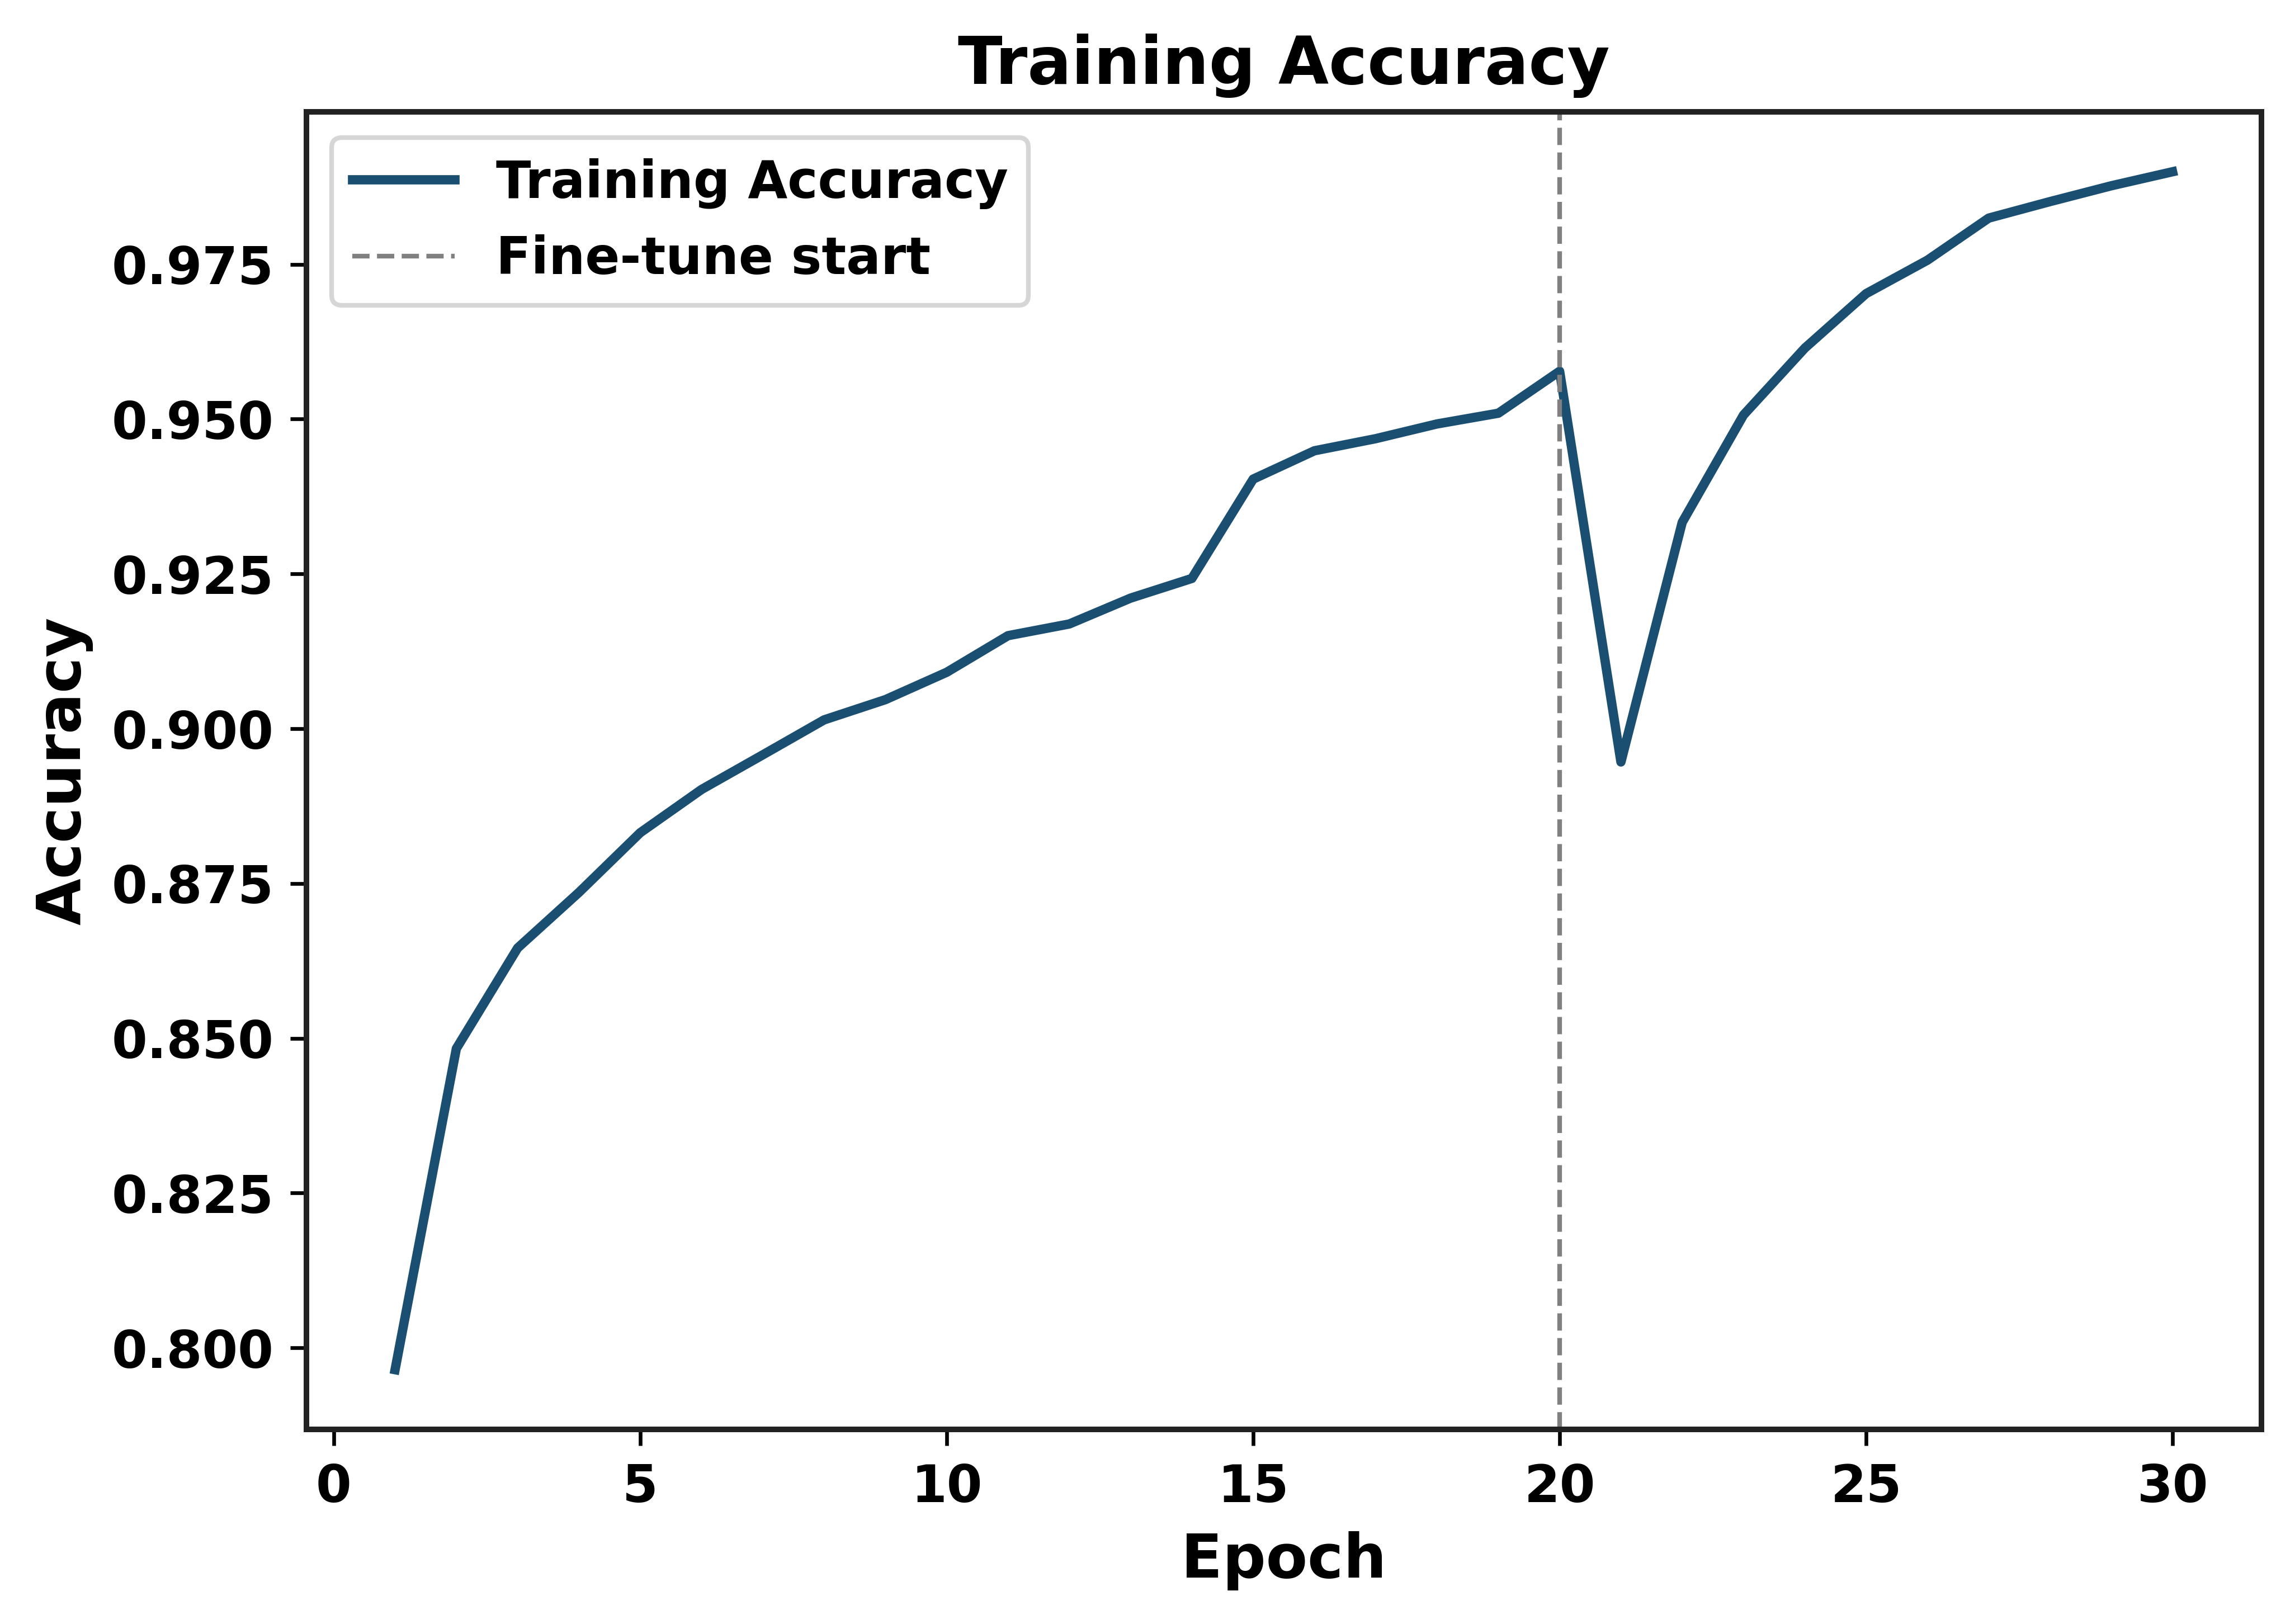

In [ ]:
# Training Accuracy plot
fig, ax = plt.subplots()
ax.plot(epochs_range, acc, color=PALETTE[0], linewidth=2, label="Training Accuracy")
ax.axvline(ft_start_epoch, color="gray", linestyle="--", linewidth=1, label="Fine-tune start")
ax.set_xlabel("Epoch", fontweight="bold")
ax.set_ylabel("Accuracy", fontweight="bold")
ax.set_title("Training Accuracy", fontweight="bold")
leg = ax.legend()
plt.setp(leg.get_texts(), fontweight="bold")
plt.tight_layout()
save_fig(fig, "02_training_accuracy")
plt.show()

Saved: figures/03_validation_accuracy.eps


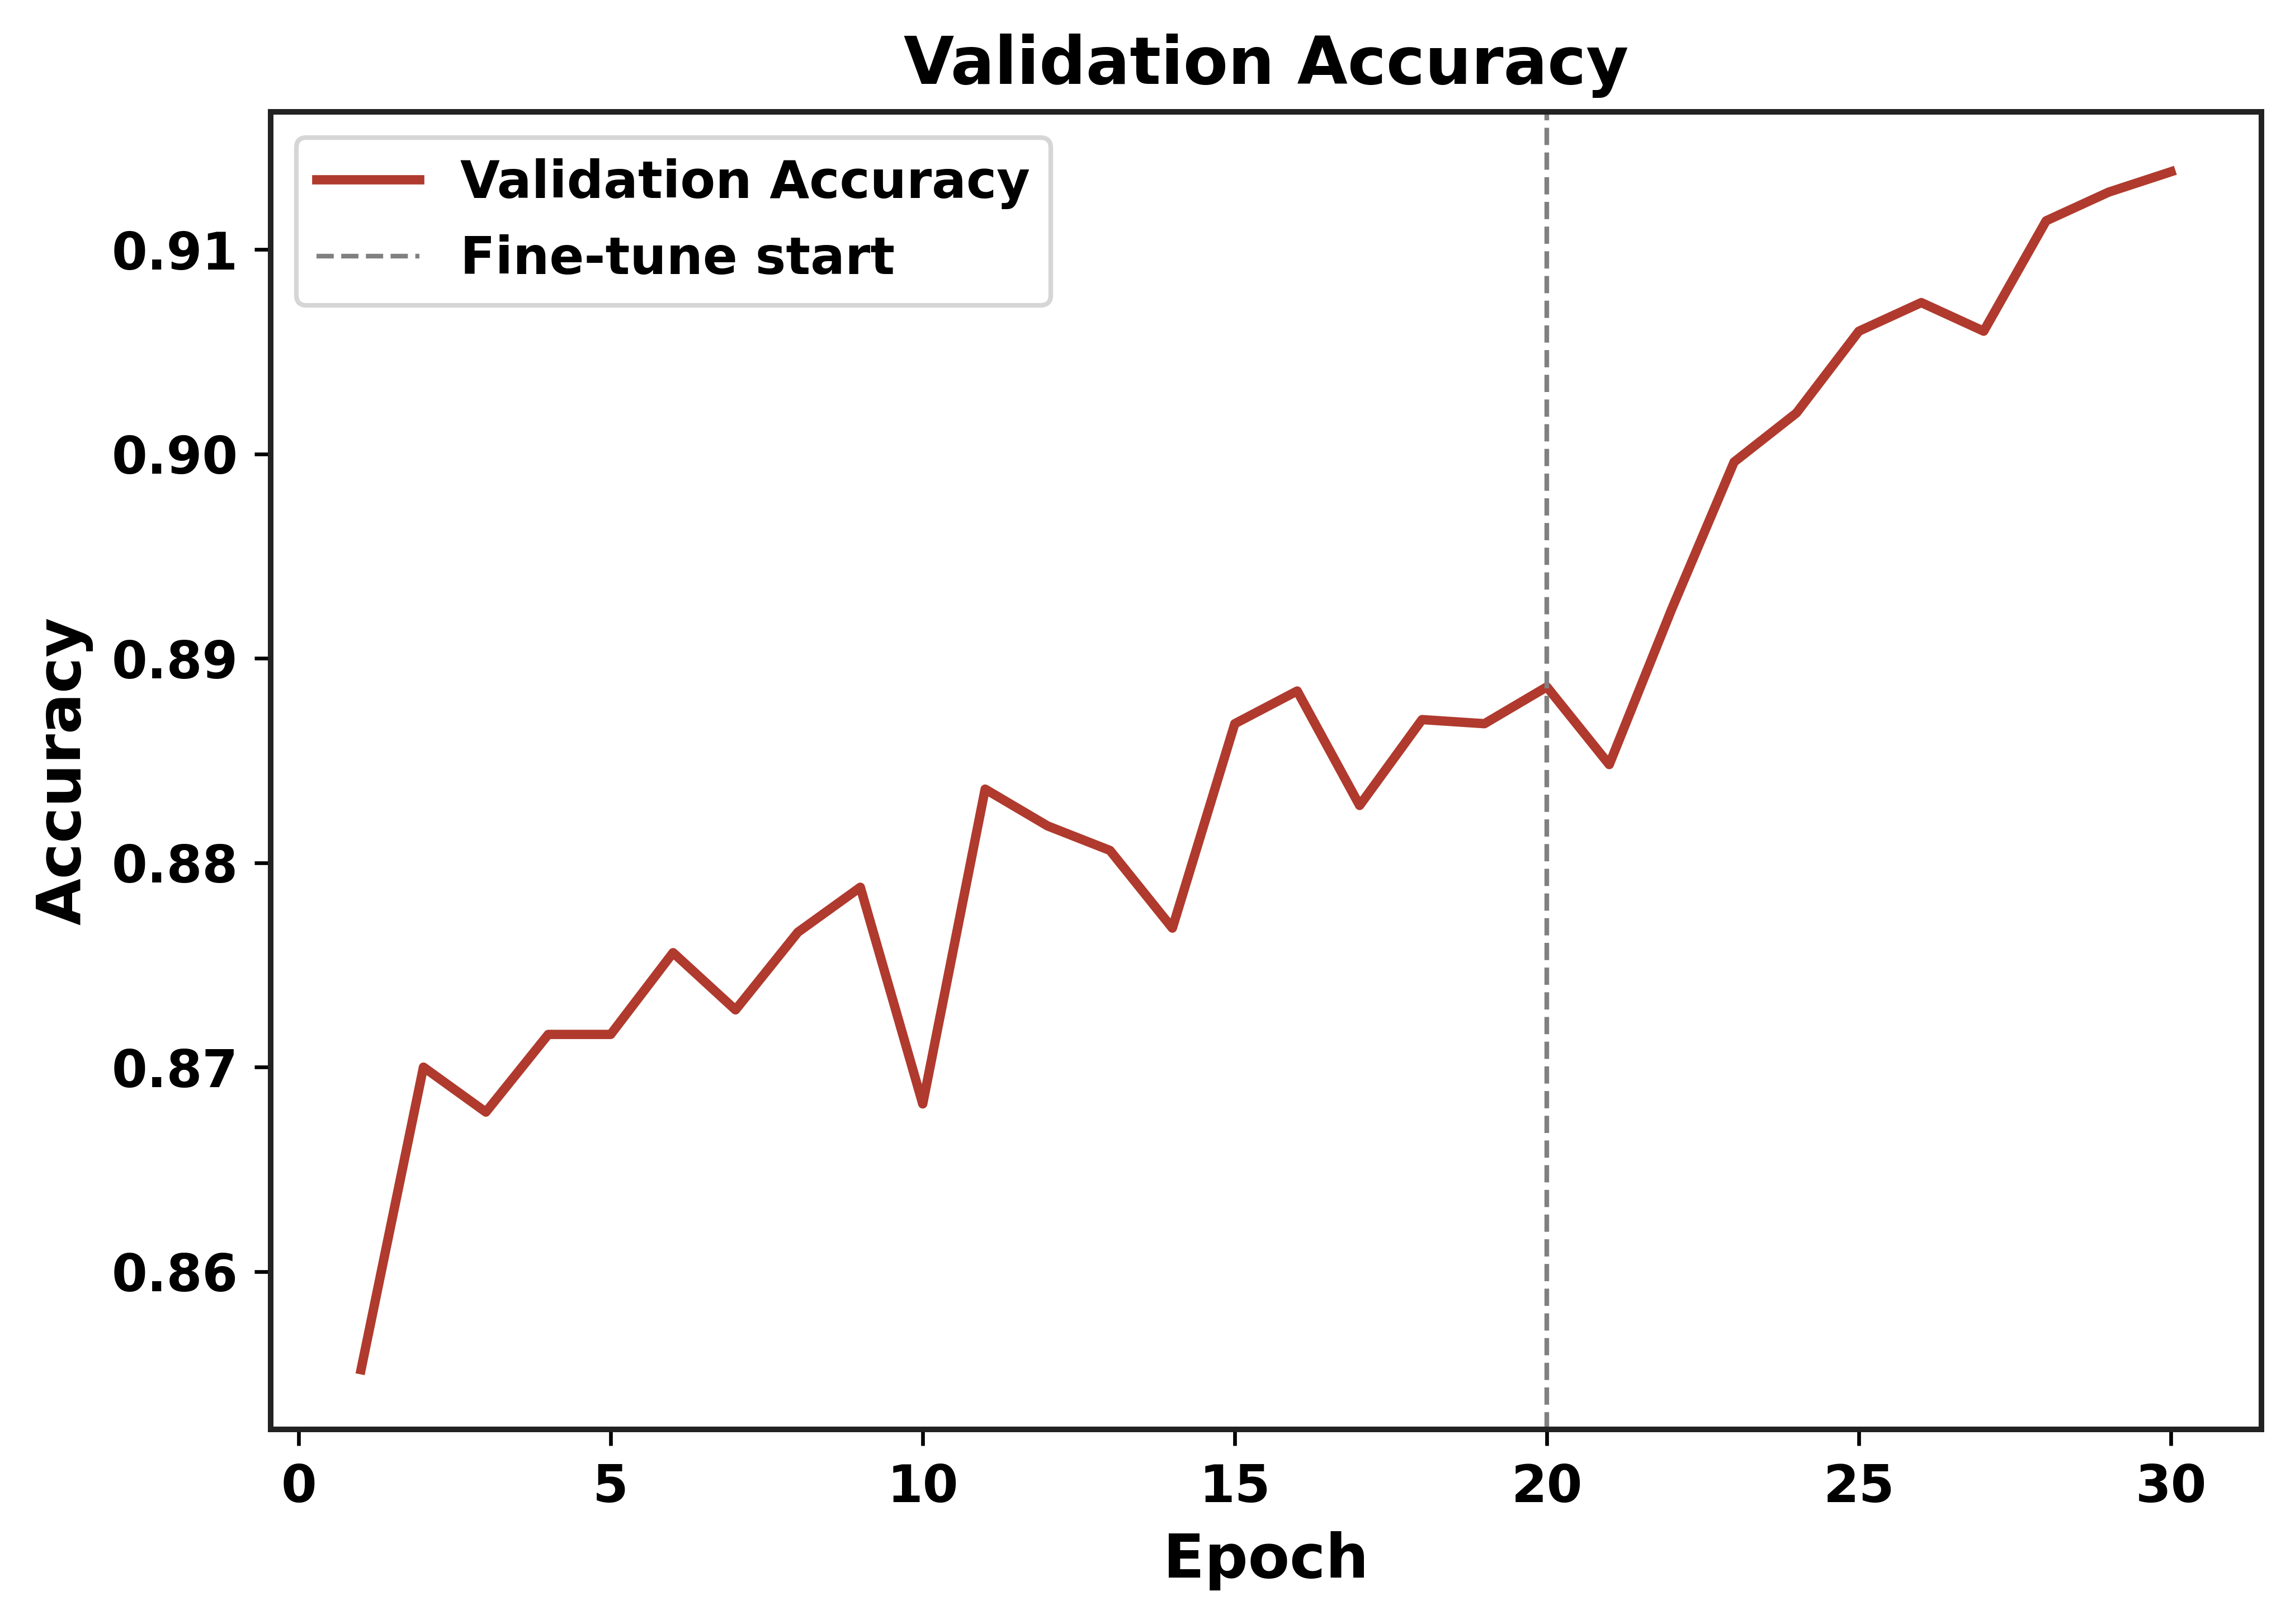

In [ ]:
# Validation Accuracy plot
fig, ax = plt.subplots()
ax.plot(epochs_range, val_acc, color=PALETTE[1], linewidth=2, label="Validation Accuracy")
ax.axvline(ft_start_epoch, color="gray", linestyle="--", linewidth=1, label="Fine-tune start")
ax.set_xlabel("Epoch", fontweight="bold")
ax.set_ylabel("Accuracy", fontweight="bold")
ax.set_title("Validation Accuracy", fontweight="bold")
leg = ax.legend()
plt.setp(leg.get_texts(), fontweight="bold")
plt.tight_layout()
save_fig(fig, "03_validation_accuracy")
plt.show()

Saved: figures/04_training_loss.eps


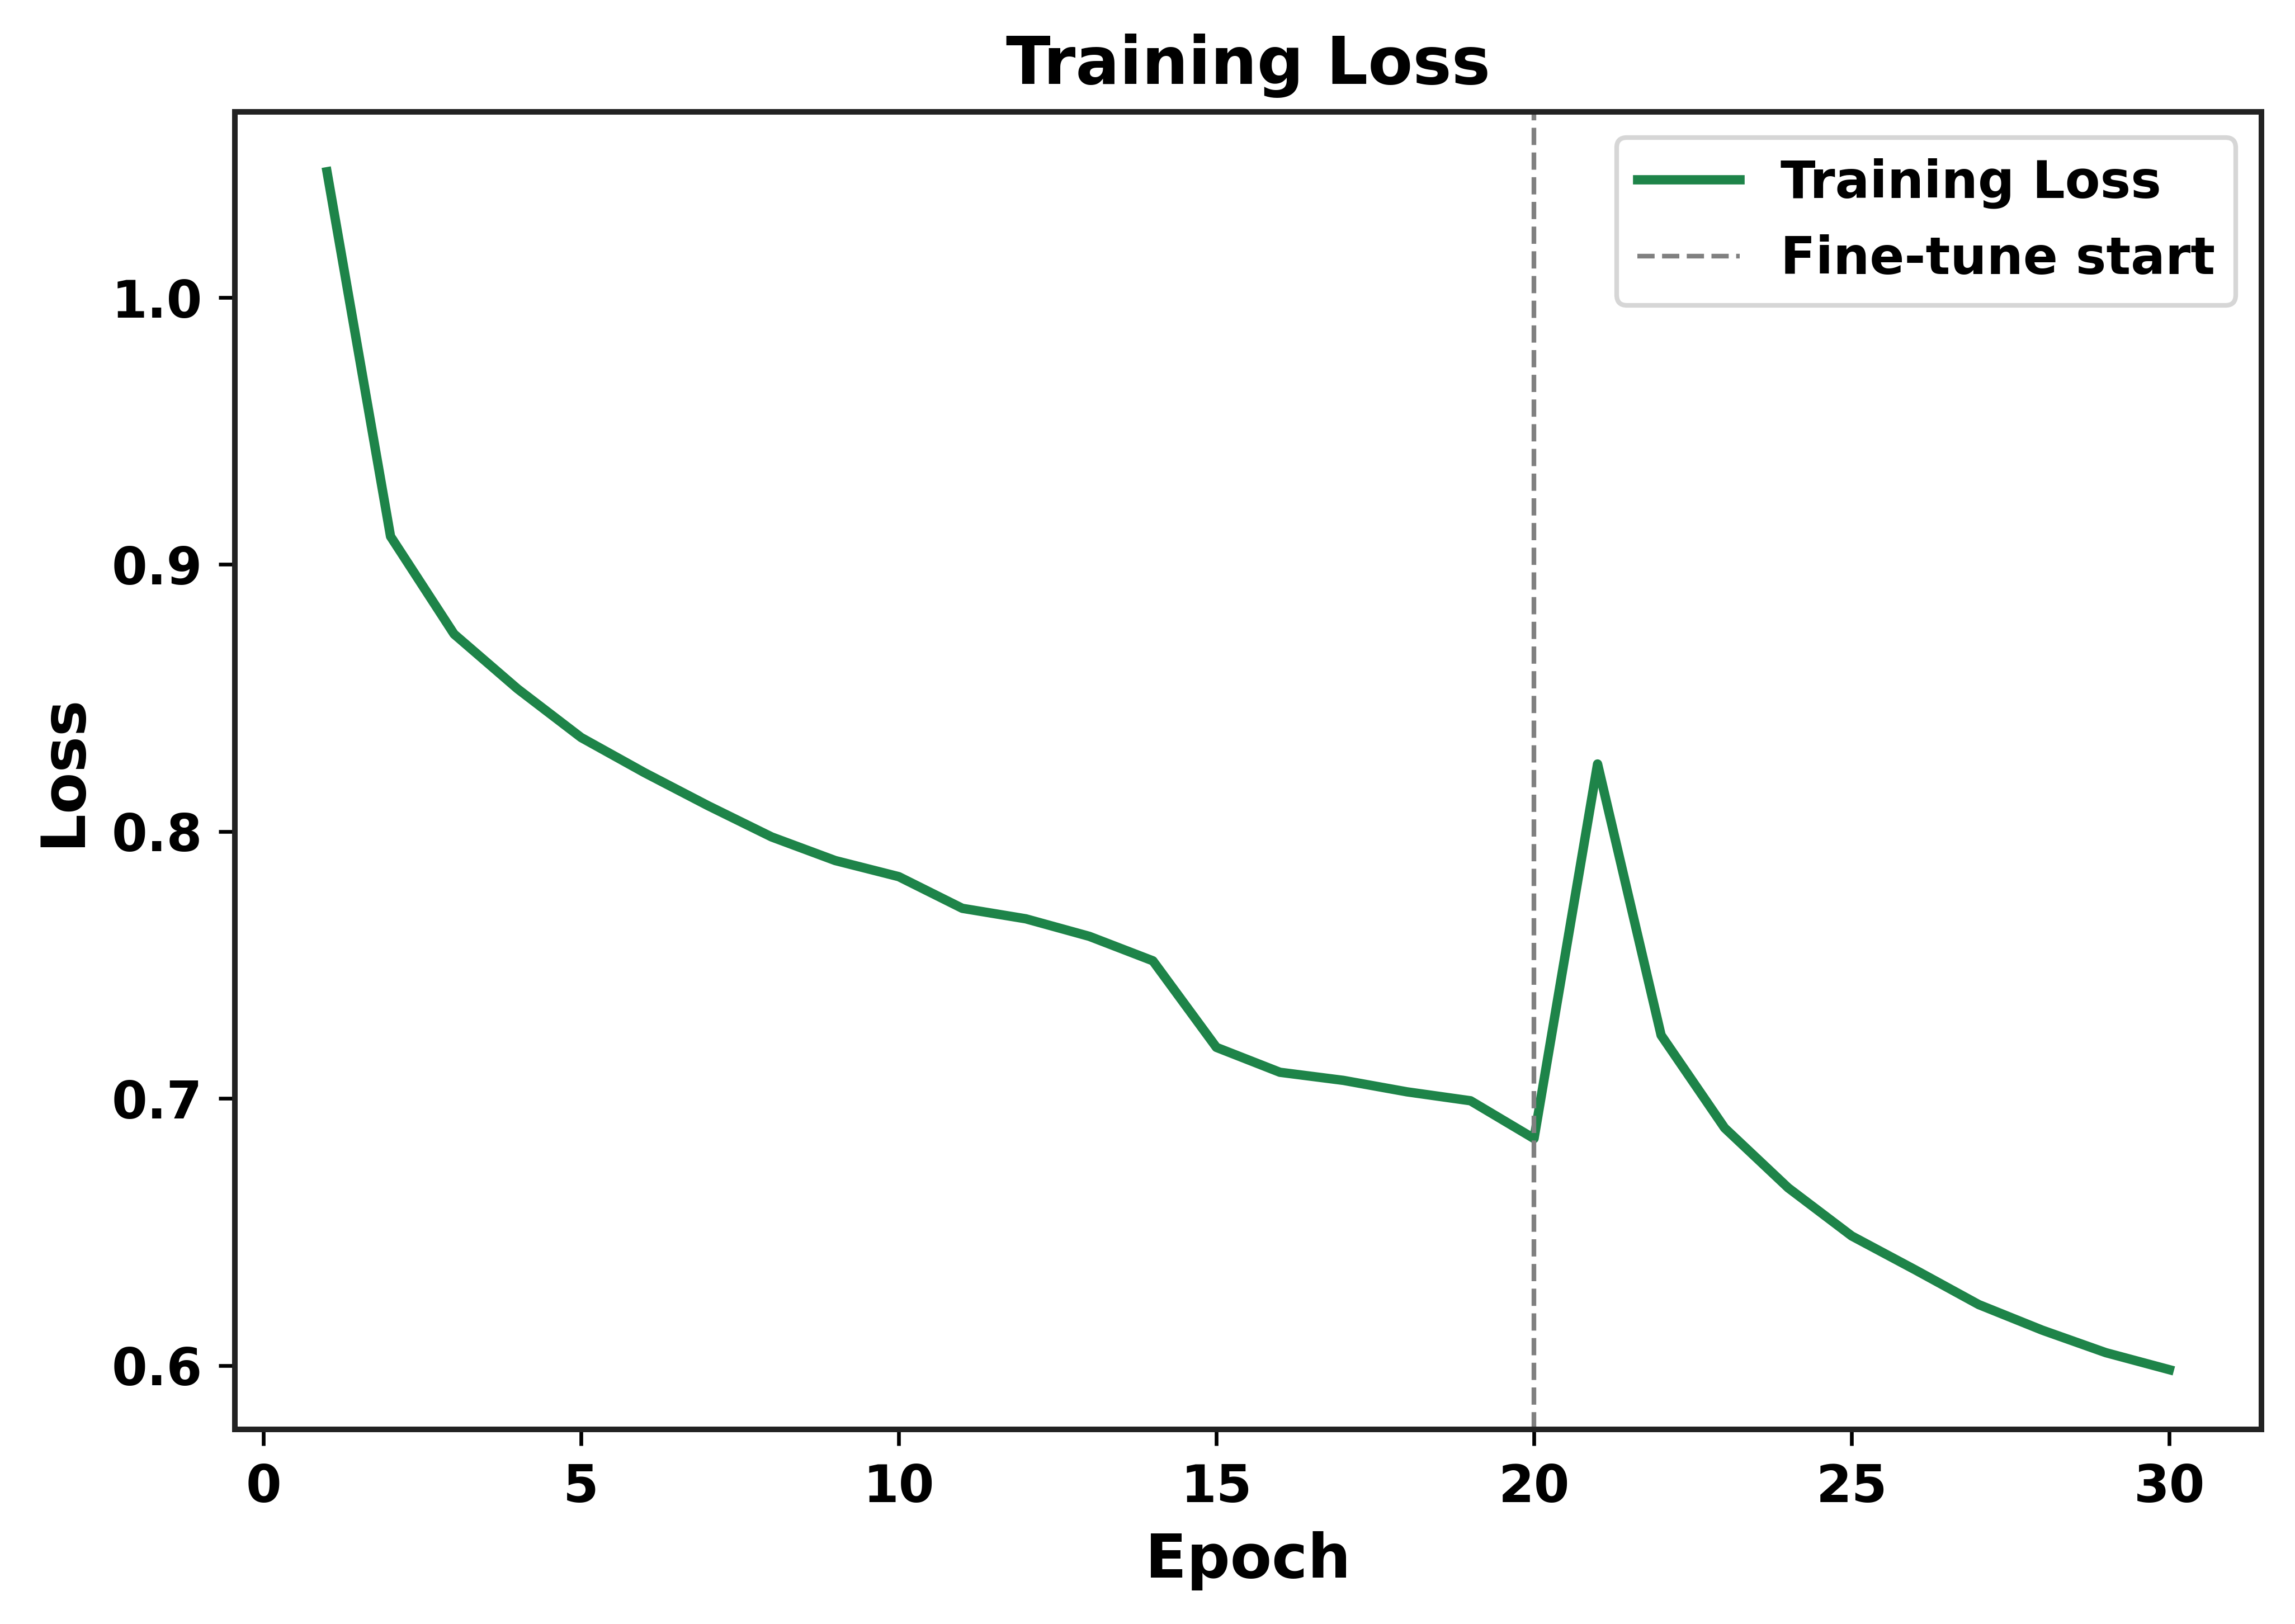

In [ ]:
# Training Loss plot
fig, ax = plt.subplots()
ax.plot(epochs_range, loss, color=PALETTE[2], linewidth=2, label="Training Loss")
ax.axvline(ft_start_epoch, color="gray", linestyle="--", linewidth=1, label="Fine-tune start")
ax.set_xlabel("Epoch", fontweight="bold")
ax.set_ylabel("Loss", fontweight="bold")
ax.set_title("Training Loss", fontweight="bold")
leg = ax.legend()
plt.setp(leg.get_texts(), fontweight="bold")
plt.tight_layout()
save_fig(fig, "04_training_loss")
plt.show()

Saved: figures/05_validation_loss.eps


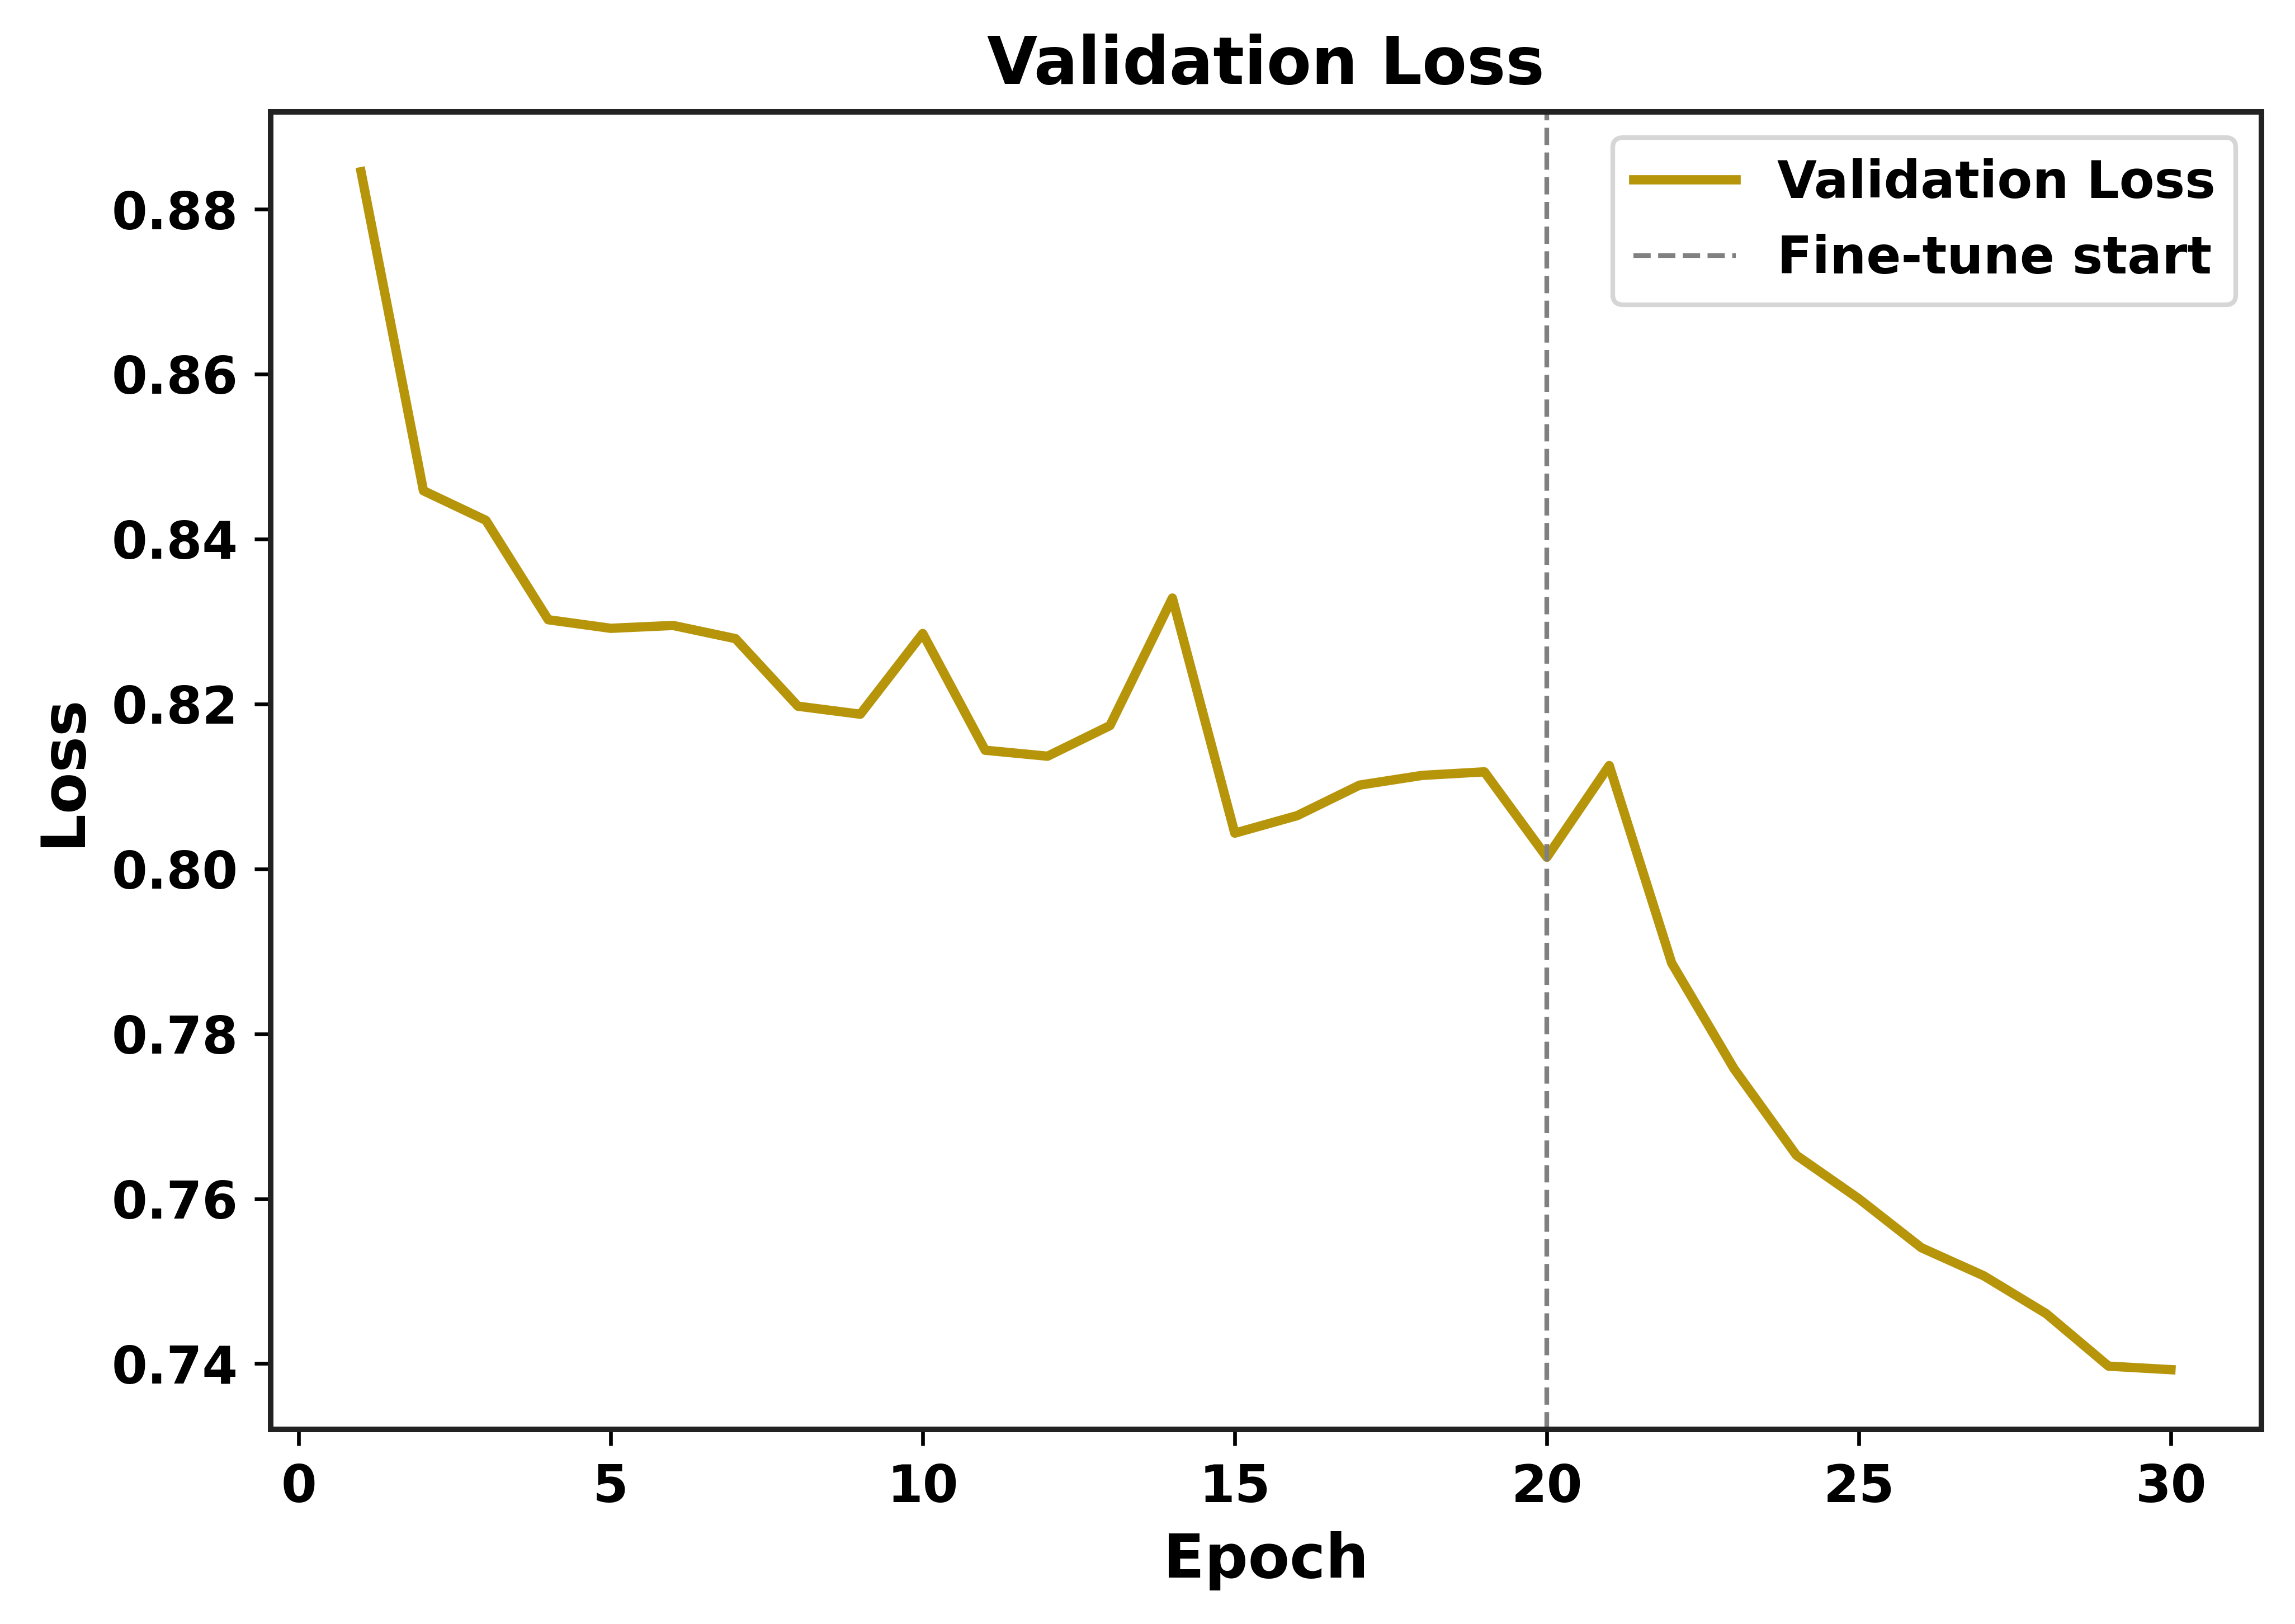

In [ ]:
# Validation Loss plot
fig, ax = plt.subplots()
ax.plot(epochs_range, val_loss, color=PALETTE[3], linewidth=2, label="Validation Loss")
ax.axvline(ft_start_epoch, color="gray", linestyle="--", linewidth=1, label="Fine-tune start")
ax.set_xlabel("Epoch", fontweight="bold")
ax.set_ylabel("Loss", fontweight="bold")
ax.set_title("Validation Loss", fontweight="bold")
leg = ax.legend()
plt.setp(leg.get_texts(), fontweight="bold")
plt.tight_layout()
save_fig(fig, "05_validation_loss")
plt.show()

In [ ]:
# ---------------------------------------------------------------
# TASK 5: Model Evaluation
# ---------------------------------------------------------------
test_loss, test_accuracy = model.evaluate(test_ds, verbose=1)
print(f"Test Accuracy: {test_accuracy*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test

precision = precision_score(y_true, y_pred, average="weighted")
recall = recall_score(y_true, y_pred, average="weighted")
f1 = f1_score(y_true, y_pred, average="weighted")
accuracy = accuracy_score(y_true, y_pred)

total_params = model.count_params()

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")
print(f"Total Parameters: {total_params:,}")
print(f"Total Training Time: {total_training_time:.2f} sec")

157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 81ms/step - accuracy: 0.9055 - loss: 0.7563
Test Accuracy: 90.55%
Test Loss: 0.7563
157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 59ms/step
Precision : 0.9055
Recall    : 0.9055
F1-score  : 0.9053
Total Parameters: 24,114,826
Total Training Time: 1084.36 sec


Saved: figures/06_confusion_matrix.eps


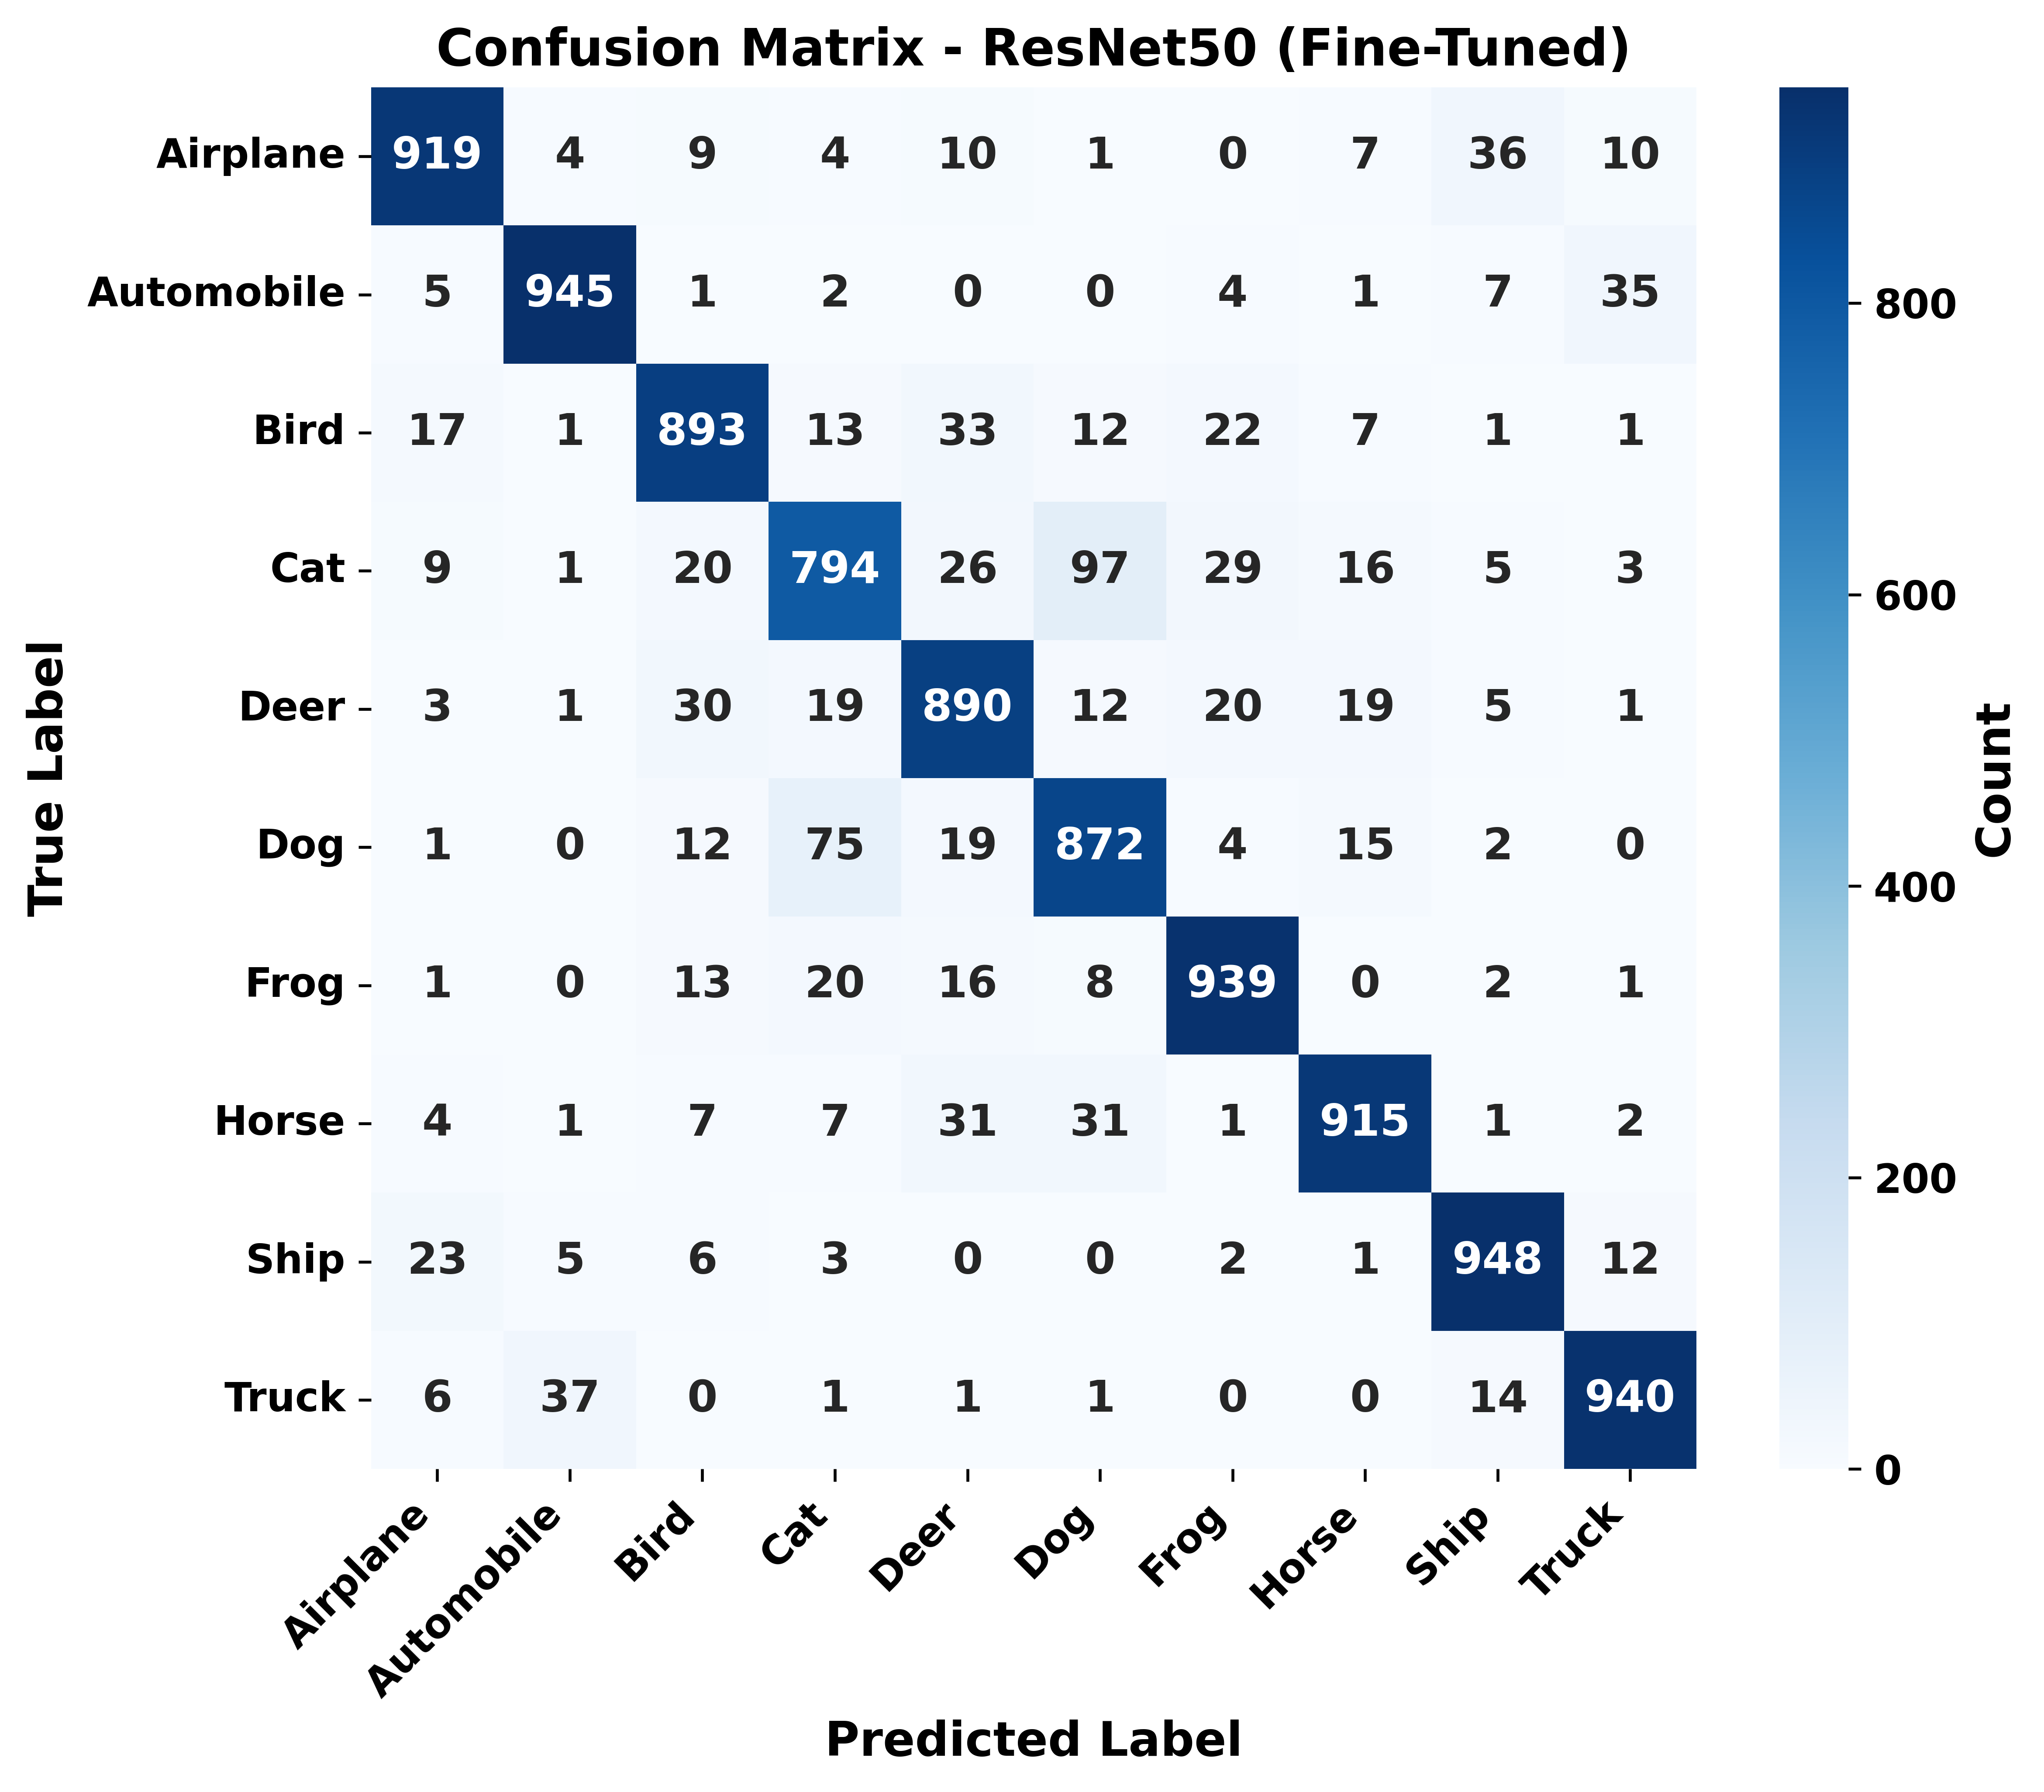

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=class_names, yticklabels=class_names,
    cbar_kws={"label": "Count"}, ax=ax,
    annot_kws={"fontweight": "bold"}
)
ax.set_xlabel("Predicted Label", fontweight="bold")
ax.set_ylabel("True Label", fontweight="bold")
ax.set_title("Confusion Matrix - ResNet50 (Fine-Tuned)", fontweight="bold")
plt.setp(ax.get_xticklabels(), fontweight="bold", rotation=45, ha="right")
plt.setp(ax.get_yticklabels(), fontweight="bold", rotation=0)
plt.tight_layout()
save_fig(fig, "06_confusion_matrix")
plt.show()

In [ ]:
print("Classification Report")
print(classification_report(y_true, y_pred, target_names=class_names))

Classification Report
              precision    recall  f1-score   support

    Airplane       0.93      0.92      0.92      1000
  Automobile       0.95      0.94      0.95      1000
        Bird       0.90      0.89      0.90      1000
         Cat       0.85      0.79      0.82      1000
        Deer       0.87      0.89      0.88      1000
         Dog       0.84      0.87      0.86      1000
        Frog       0.92      0.94      0.93      1000
       Horse       0.93      0.92      0.92      1000
        Ship       0.93      0.95      0.94      1000
       Truck       0.94      0.94      0.94      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



Saved: figures/07_misclassified_images.eps


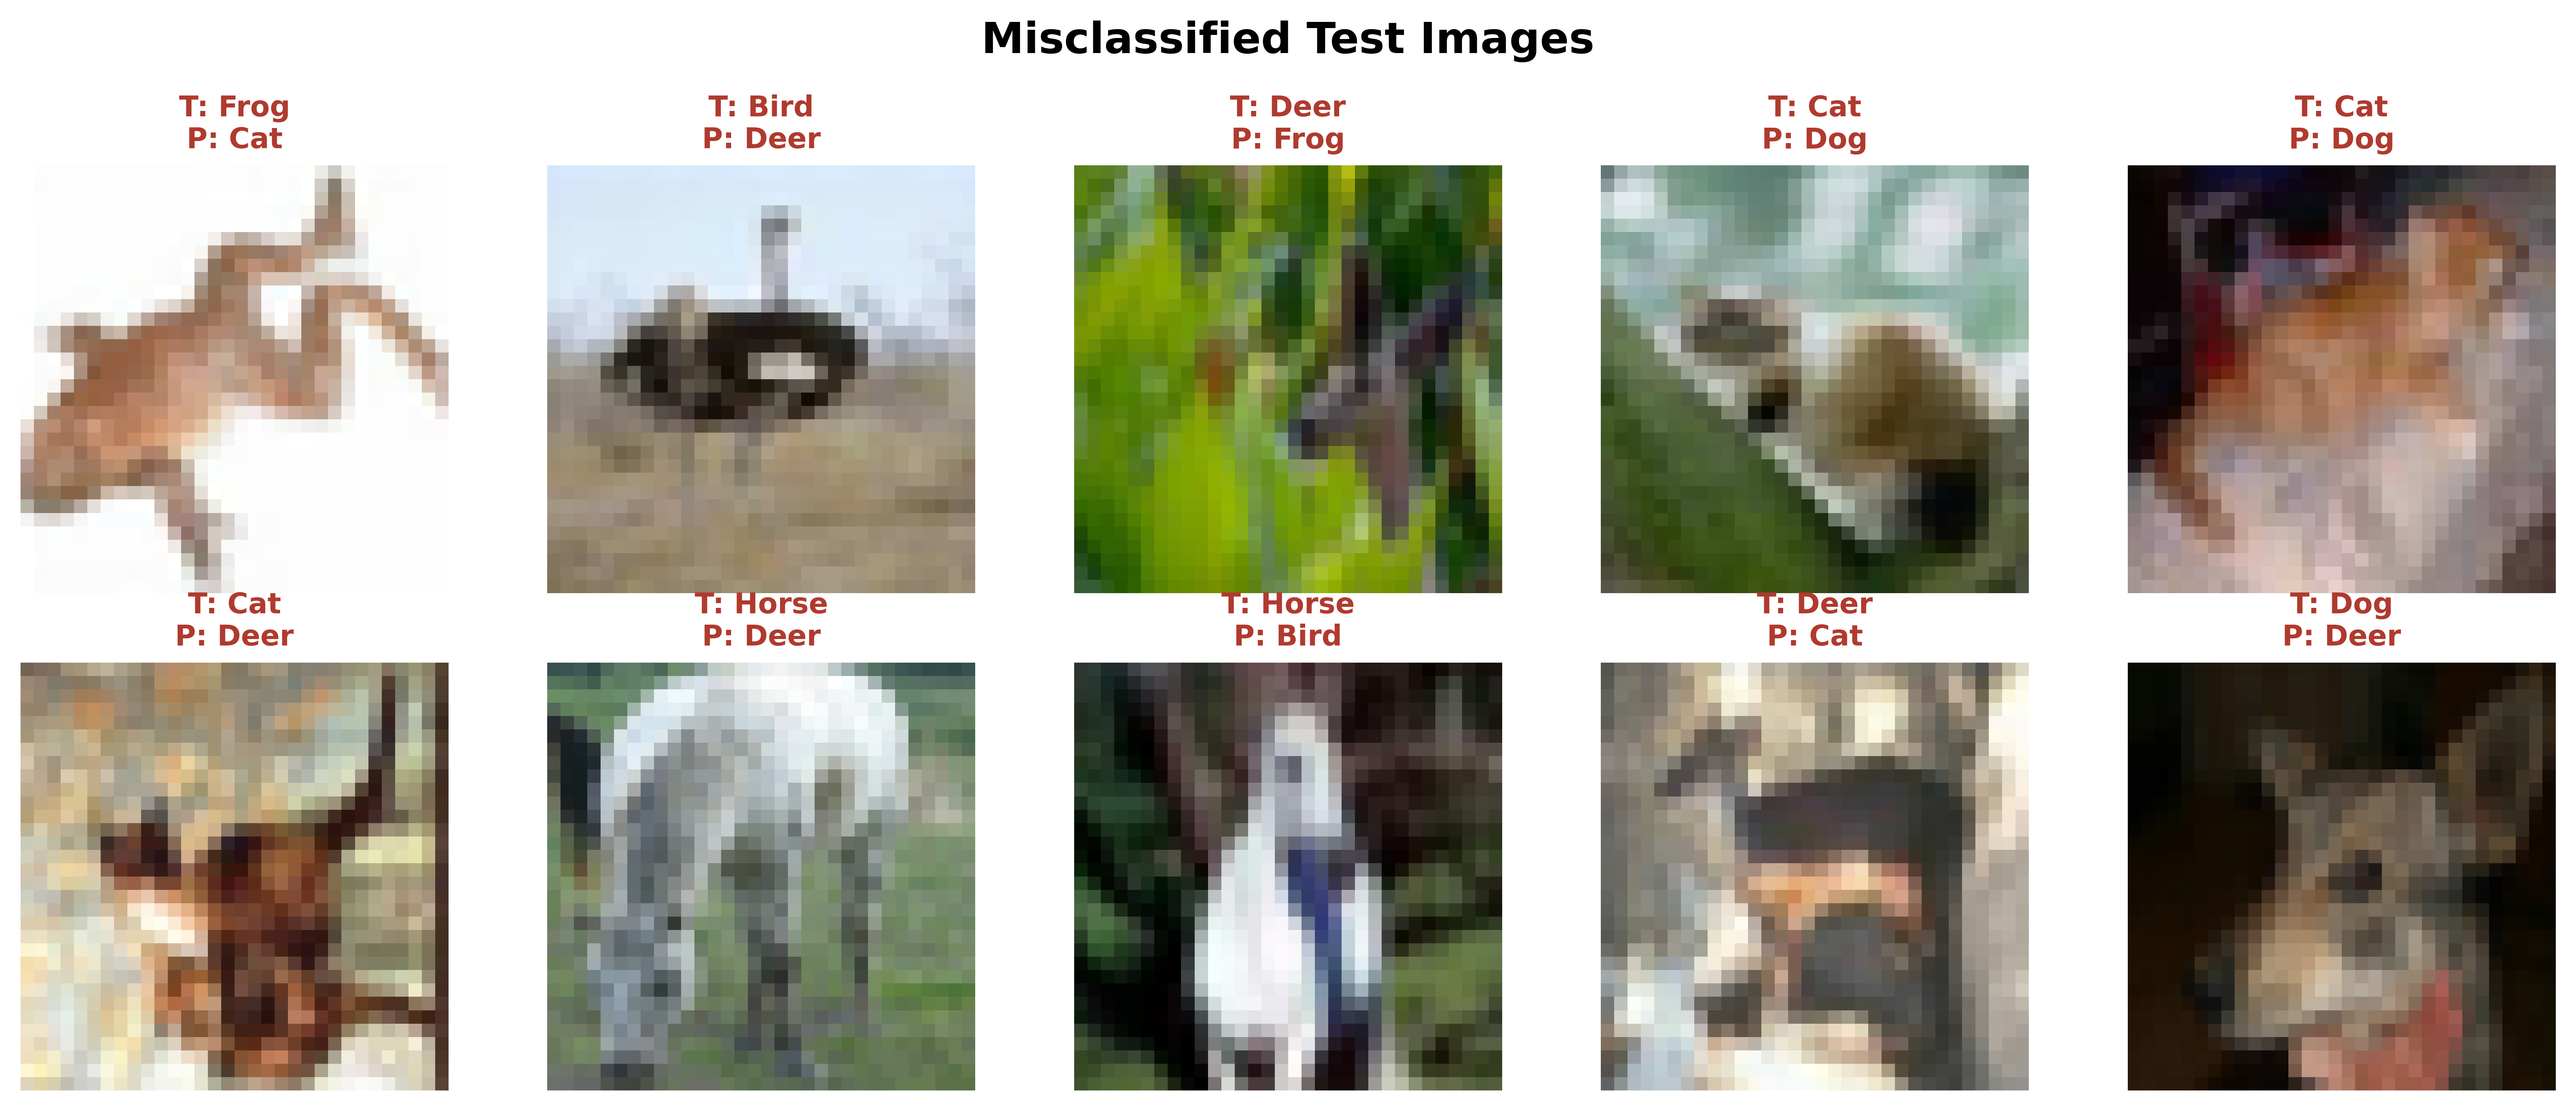

In [ ]:
# Misclassified Images (Optional)
misclassified_idx = np.where(y_pred != y_true)[0]
sample_idx = np.random.default_rng(SEED).choice(
    misclassified_idx, min(10, len(misclassified_idx)), replace=False
)

fig, axes = plt.subplots(2, 5, figsize=(13, 5.5))
for ax, idx in zip(axes.ravel(), sample_idx):
    ax.imshow(x_test[idx])
    ax.set_title(
        f"T: {class_names[y_true[idx]]}\nP: {class_names[y_pred[idx]]}",
        fontsize=10, fontweight="bold", color=PALETTE[1]
    )
    ax.axis("off")

fig.suptitle("Misclassified Test Images", fontweight="bold", fontsize=15)
plt.tight_layout()
save_fig(fig, "07_misclassified_images")
plt.show()

In [ ]:
# ---------------------------------------------------------------
# Results Summary Table (Section 18.1)
# ---------------------------------------------------------------
results_summary = pd.DataFrame({
    "Metric": ["Training Accuracy", "Testing Accuracy", "Precision",
               "Recall", "F1-score", "Training Time (s)", "Total Parameters"],
    "Value": [
        f"{acc[-1]*100:.2f}%",
        f"{test_accuracy*100:.2f}%",
        f"{precision:.4f}",
        f"{recall:.4f}",
        f"{f1:.4f}",
        f"{total_training_time:.2f}",
        f"{total_params:,}"
    ]
})
results_summary

,Metric,Value
0,Training Accuracy,99.00%
1,Testing Accuracy,90.55%
2,Precision,0.9055
3,Recall,0.9055
4,F1-score,0.9053
5,Training Time (s),1084.36
6,Total Parameters,"24,114,826"


In [ ]:
# ---------------------------------------------------------------
# Comparison of CNN Architectures (Section 18.2) - reference figures
# from literature for LeNet-5 / AlexNet / VGG16 / GoogleNet, plus the
# measured value for the ResNet50 model trained above.
# ---------------------------------------------------------------
architecture_comparison = pd.DataFrame({
    "Model": ["LeNet-5", "AlexNet", "VGG16", "GoogleNet", "ResNet50 (this run)"],
    "Parameters": ["60K", "61M", "138M", "6.8M", f"{total_params:,}"],
    "Accuracy (%)": ["~99 (MNIST)", "~57 (CIFAR-10, scratch)",
                      "~93 (CIFAR-10, TL)", "~94 (CIFAR-10, TL)",
                      f"{test_accuracy*100:.2f}"],
    "Training Time": ["Seconds", "Minutes", "~Hours (from scratch)",
                       "~Hours (from scratch)", f"{total_training_time:.2f} s"]
})
architecture_comparison

,Model,Parameters,Accuracy (%),Training Time
0,LeNet-5,60K,~99 (MNIST),Seconds
1,AlexNet,61M,"~57 (CIFAR-10, scratch)",Minutes
2,VGG16,138M,"~93 (CIFAR-10, TL)",~Hours (from scratch)
3,GoogleNet,6.8M,"~94 (CIFAR-10, TL)",~Hours (from scratch)
4,ResNet50 (this run),"24,114,826",90.55,1084.36 s


Saved: figures/08_architecture_comparison.eps


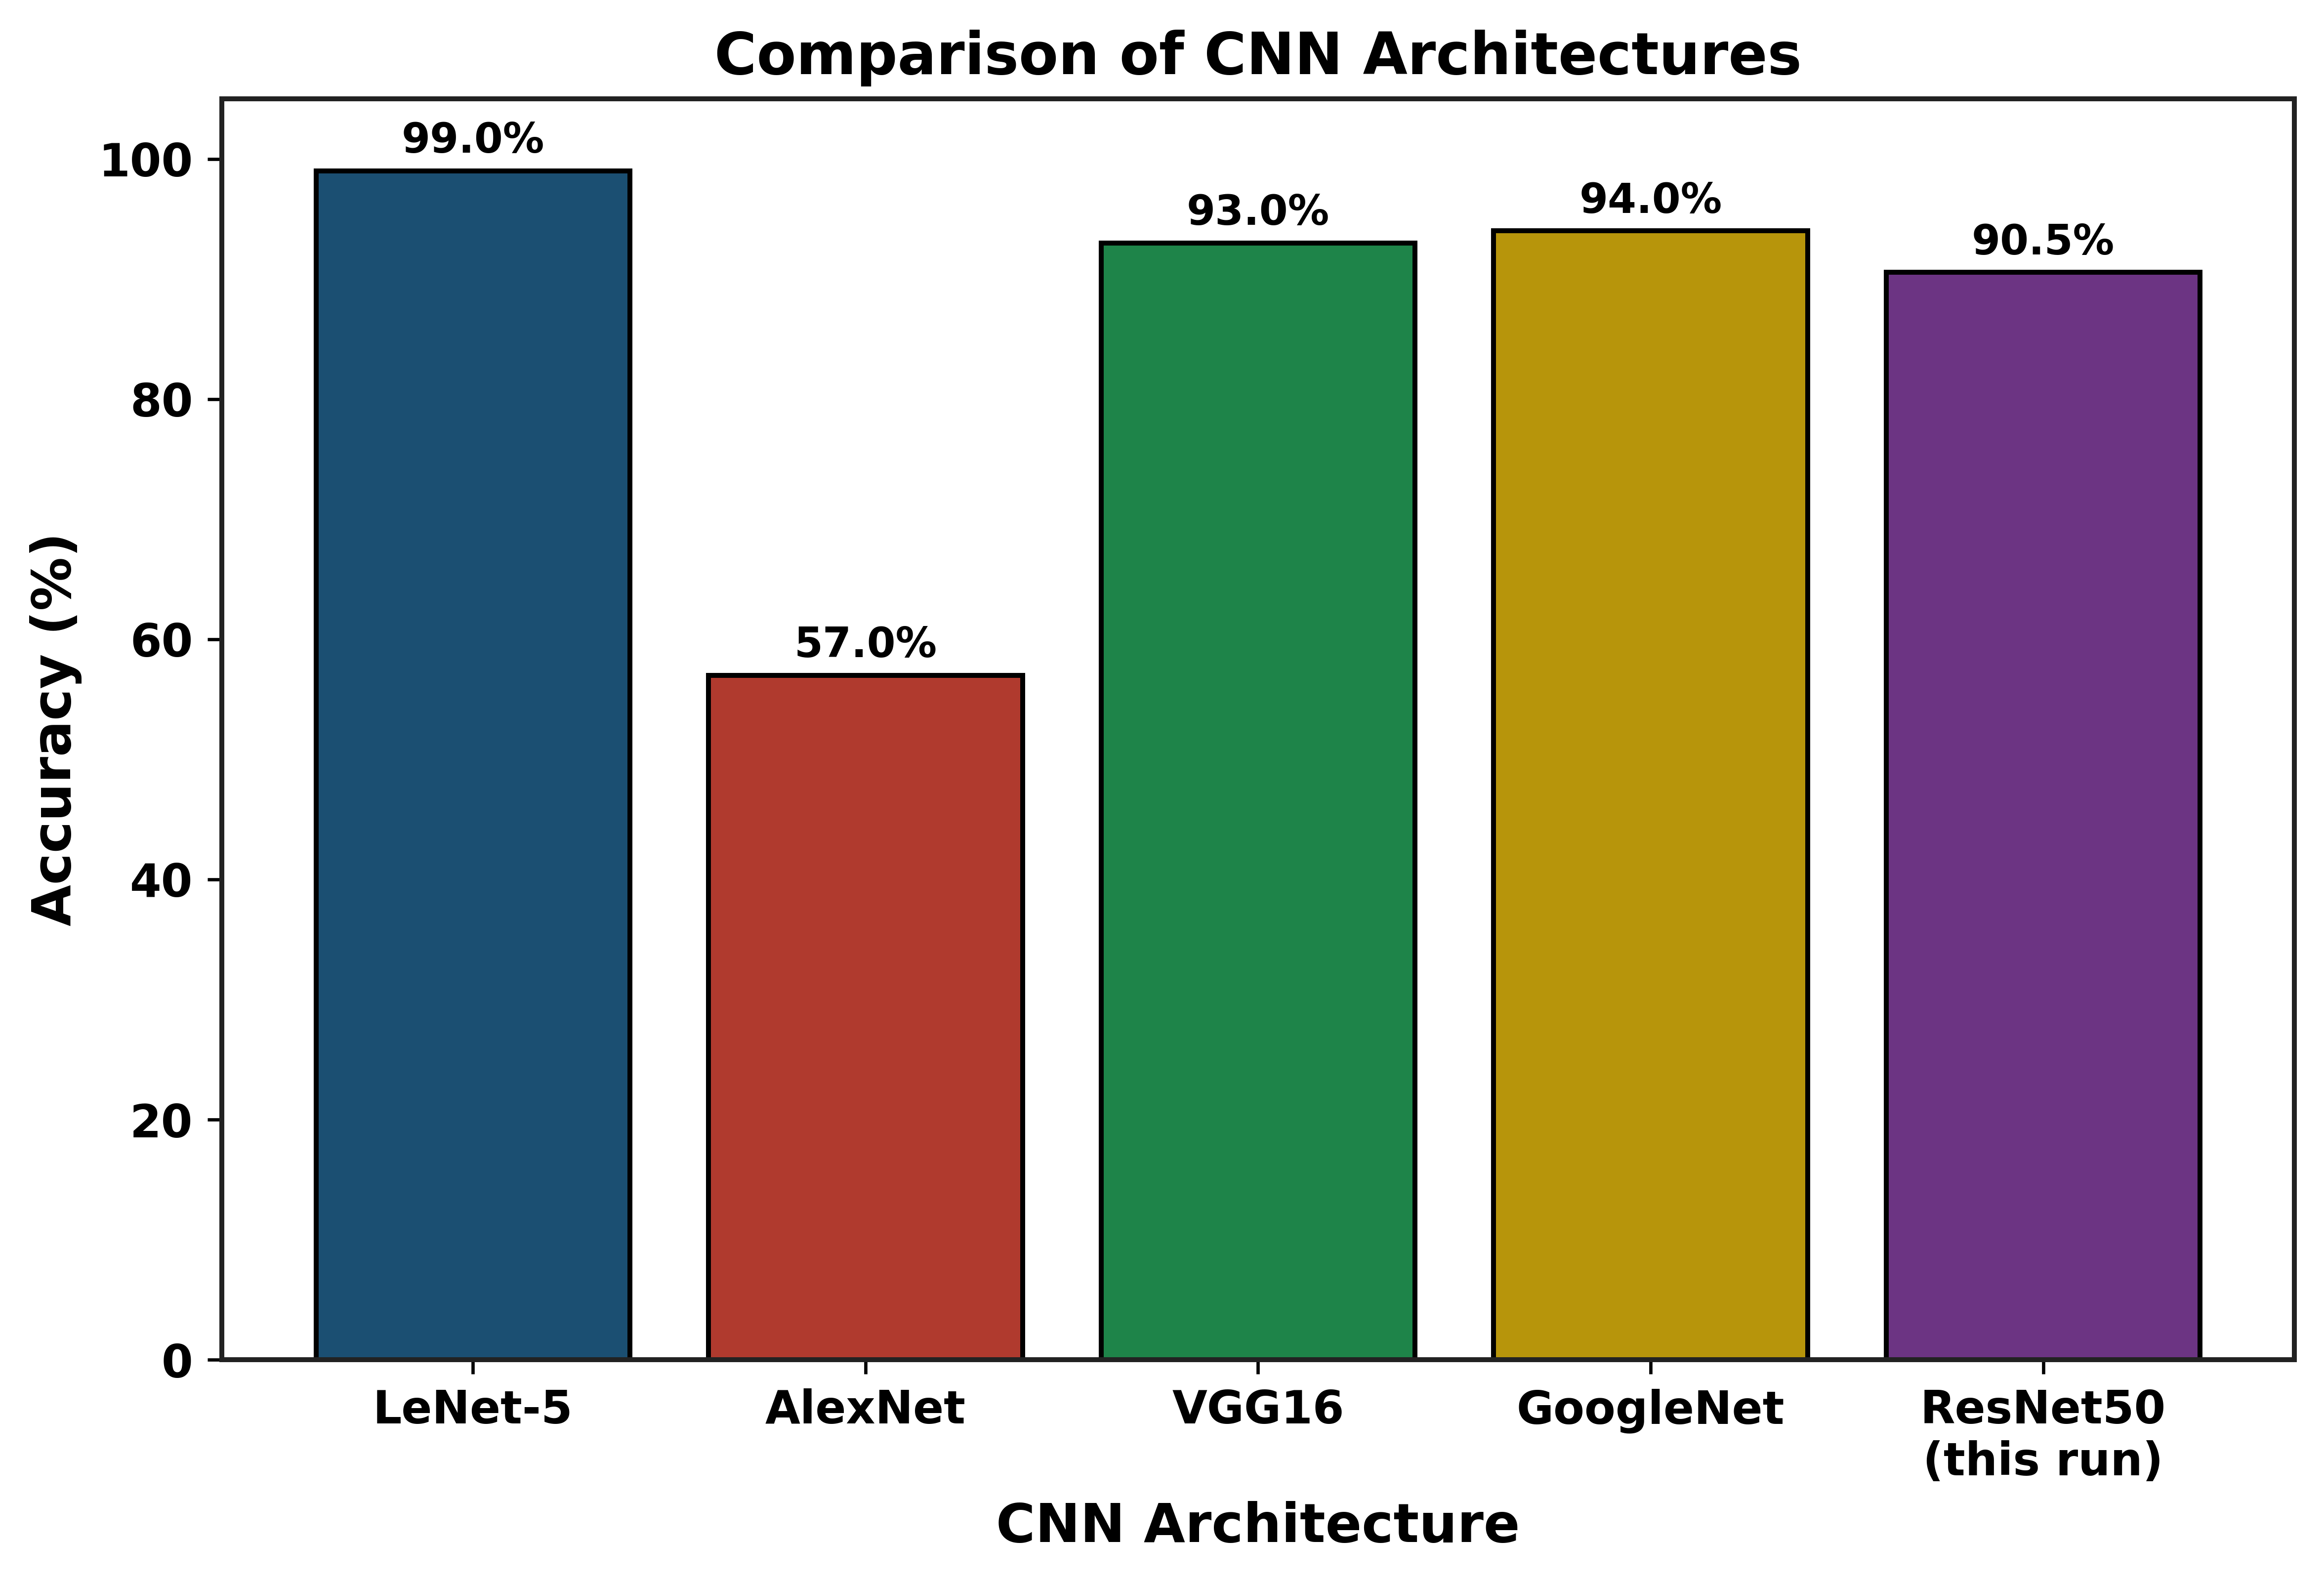

In [ ]:
# Bar chart: architecture comparison accuracy (Optional supplementary plot)
acc_values = [99, 57, 93, 94, test_accuracy * 100]
model_labels = ["LeNet-5", "AlexNet", "VGG16", "GoogleNet", "ResNet50\n(this run)"]

fig, ax = plt.subplots(figsize=(8, 5.5))
bars = ax.bar(model_labels, acc_values, color=PALETTE[:5], edgecolor="black", linewidth=1.2)
ax.set_xlabel("CNN Architecture", fontweight="bold")
ax.set_ylabel("Accuracy (%)", fontweight="bold")
ax.set_title("Comparison of CNN Architectures", fontweight="bold")
ax.set_ylim(0, 105)
for bar, val in zip(bars, acc_values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1.5, f"{val:.1f}%",
            ha="center", fontweight="bold", fontsize=10)
plt.setp(ax.get_xticklabels(), fontweight="bold")
plt.setp(ax.get_yticklabels(), fontweight="bold")
plt.tight_layout()
save_fig(fig, "08_architecture_comparison")
plt.show()

In [ ]:
# ---------------------------------------------------------------
# Save final model
# ---------------------------------------------------------------
model.save("resnet50_cifar10_finetuned.keras")
print("Model saved as resnet50_cifar10_finetuned.keras")

Model saved as resnet50_cifar10_finetuned.keras
